# 구글 드라이브 연결

In [1]:
# 구글 드라이브 연결(데이터 로드를 위해서)
from google.colab import drive

drive.mount('/content/data')

Mounted at /content/data


# Install

In [2]:
!pip install -r "/content/data/MyDrive/ai_lecture/6. Recommendation System/2. 비개인화 추천 예제/requirements.txt"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 820.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

## 데이터(파일) 설명

- movies_metadata.csv
  - 주요 영화 메타데이터 파일입니다.
  - Full MovieLens 데이터세트에 포함된 45,000편의 영화에 대한 정보가 포함되어 있습니다.
  - 포스터, 배경, 예산, 수익, 개봉일, 언어, 제작 국가 및 제작사 등의 정보가 포함됩니다.
- keywords.csv
  - MovieLens 영화의 줄거리 키워드를 담고 있습니다.
  - 문자열화된 JSON 객체 형태로 제공됩니다.
- links_small.csv
  - 전체 데이터 세트의 9,000개 영화 중 작은 하위 세트의 TMDB 및 IMDB ID를 포함합니다.

# 데이터

In [3]:
DATA_PATH = "/content/data/MyDrive/ai_lecture/6. Recommendation System/data/Movies Dataset/"

In [4]:
import pandas as pd
from ast import literal_eval

## 데이터 로드

> movies_metadata는 영화에 대한 메타데이터(제목, 장르 등)이다.

In [5]:
movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')

movies_metadata.shape

/tmp/ipython-input-5-2843536420.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')


(45466, 24)

> links_small.csv를 이용하여 movies_metadata의 데이터 수를 줄이자   
> 너무 데이터가 많으면, 전처리 및 추천할 때, 시간이 오래 걸리거나 메모리가 부족한 경우가 발생할 수 있다.

In [6]:
links_small = pd.read_csv(DATA_PATH+'links_small.csv')

links_small.shape

(9125, 3)

In [7]:
# 결측치 제거 및 데이터 형변환
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')

# links_small에 포함된 id만 사용
movies_metadata_small = movies_metadata[movies_metadata['id'].isin(links_small.astype('str'))]
movies_metadata_small.shape

(9099, 24)

> 추천에 필요한 컬럼만 사용하기   
> title(영화 제목), genres(영화 장르), popularity(영화 인기도), release_date(영화 개볼일)

In [8]:
columns = ['id', 'title', 'genres', 'popularity', 'release_date']

movies = movies_metadata_small[columns]
movies.head()

,id,title,genres,popularity,release_date
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943,1995-10-30
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539,1995-12-15
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129,1995-12-22
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495,1995-12-22
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",8.387519,1995-02-10


> keywords는 영화에 대한 키워드 데이터이다.

In [9]:
movies_keywords = pd.read_csv(DATA_PATH+'keywords.csv')

movies_keywords.columns

Index(['id', 'keywords'], dtype='object')

## 데이터 합치기

In [10]:
movies['id'] = movies['id'].astype('str')
movies_keywords['id'] = movies_keywords['id'].astype('str')

# 영화 아이디(id)를 기준으로 데이터를 합치기
movies = movies.merge(movies_keywords, on=['id'])
# 결과 확인
movies.head()

/tmp/ipython-input-10-85336531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['id'] = movies['id'].astype('str')


,id,title,genres,popularity,release_date,keywords
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943,1995-10-30,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539,1995-12-15,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129,1995-12-22,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495,1995-12-22,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",8.387519,1995-02-10,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


## 데이터 전처리

### genres 추출    
> 추천을 할때 genres(장르)가 비슷한 영화들을 추천하자

In [11]:
movies[['genres']].loc[0].values[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

```python
# genres(장르)에서 [] 데이터는 제외하고
movies['genres'].fillna('[]')\
  # 문자열을 dictionary 데이터로 변환
  .apply(literal_eval)\
  # 장르 데이터를 추출해서 리스트에 넣기
  .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])

```

In [12]:
movies['genres'] = movies['genres'].fillna('[]')\
                    .apply(literal_eval)\
                    .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])

movies[['genres']].head()

,genres
0,"[Animation, Comedy, Family]"
1,"[Adventure, Family, Fantasy]"
2,"[Comedy, Romance]"
3,"[Comedy, Drama, Romance]"
4,[Comedy]


### keywords 추출    
> 추천을 할때 keywords(키워드)가 비슷한 영화들을 추천하자

In [13]:
movies[['keywords']].loc[0].values[0]

"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'friendship'}, {'id': 9713, 'name': 'friends'}, {'id': 9823, 'name': 'rivalry'}, {'id': 165503, 'name': 'boy next door'}, {'id': 170722, 'name': 'new toy'}, {'id': 187065, 'name': 'toy comes to life'}]"

```python
# keywords(키워드)에서 [] 데이터는 제외하고
movies['keywords'].fillna('[]')\
  # 문자열을 dictionary 데이터로 변환
  .apply(literal_eval)\
  # 키워드 데이터를 추출해서 리스트에 넣기
  .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])

```

In [14]:
movies['keywords'] = movies['keywords'].fillna('[]')\
                    .apply(literal_eval)\
                    .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])

movies[['keywords']].head()

,keywords
0,"[boy, boy next door, friends, friendship, jeal..."
1,"[based on children's book, board game, disappe..."
2,"[best friend, duringcreditsstinger, fishing, o..."
3,"[based on novel, chick flick, divorce, interra..."
4,"[aging, baby, confidence, contraception, daugh..."


### genres와 keywords를 합치기

In [15]:
# 장르와 키워드 데이터 합치기
movies['str_genres_keywords'] = movies['genres'] + movies['keywords']

# 합친 결과 확인
movies[['str_genres_keywords', 'genres', 'keywords']].head()

,str_genres_keywords,genres,keywords
0,"[Animation, Comedy, Family, boy, boy next door...","[Animation, Comedy, Family]","[boy, boy next door, friends, friendship, jeal..."
1,"[Adventure, Family, Fantasy, based on children...","[Adventure, Family, Fantasy]","[based on children's book, board game, disappe..."
2,"[Comedy, Romance, best friend, duringcreditsst...","[Comedy, Romance]","[best friend, duringcreditsstinger, fishing, o..."
3,"[Comedy, Drama, Romance, based on novel, chick...","[Comedy, Drama, Romance]","[based on novel, chick flick, divorce, interra..."
4,"[Comedy, aging, baby, confidence, contraceptio...",[Comedy],"[aging, baby, confidence, contraception, daugh..."


```python
# 합친(장르와 키워드) 데이터 전처리 시작...
movies['str_genres_keywords']\
  # 데이터 정렬...
  .apply(lambda x: sorted(list(x)))\
  # 하나의 문자열로 변경...
  .apply(lambda x: " ".join(x) if len(x) > 0 else None)

```

In [16]:
movies['str_genres_keywords'] = movies['str_genres_keywords']\
                                  .apply(lambda x: sorted(list(x)))\
                                  .apply(lambda x: " ".join(x) if len(x) > 0 else None)

movies[['str_genres_keywords', 'genres', 'keywords']].head()

,str_genres_keywords,genres,keywords
0,Animation Comedy Family boy boy next door frie...,"[Animation, Comedy, Family]","[boy, boy next door, friends, friendship, jeal..."
1,Adventure Family Fantasy based on children's b...,"[Adventure, Family, Fantasy]","[based on children's book, board game, disappe..."
2,Comedy Romance best friend duringcreditsstinge...,"[Comedy, Romance]","[best friend, duringcreditsstinger, fishing, o..."
3,Comedy Drama Romance based on novel chick flic...,"[Comedy, Drama, Romance]","[based on novel, chick flick, divorce, interra..."
4,Comedy aging baby confidence contraception dau...,[Comedy],"[aging, baby, confidence, contraception, daugh..."


### 개봉일(release_date) 전처리

> release_date의 문자열 데이터를 날짜 데이터로 형변환    
> 날짜 데이터로 변환하게 되면, 년/월/일 등의 데이터를 추출하기 쉬워진다.

In [17]:
# release_date의 데이터 타입이 문자열(object)임을 확인할 수 있다.
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9151 entries, 0 to 9150
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   9151 non-null   object
 1   title                9151 non-null   object
 2   genres               9151 non-null   object
 3   popularity           9151 non-null   object
 4   release_date         9151 non-null   object
 5   keywords             9151 non-null   object
 6   str_genres_keywords  9124 non-null   object
dtypes: object(7)
memory usage: 500.6+ KB


> errors='coerce'를 입력하면, 변환할 수 있는 데이터는 수치형으로 변환되고 변환할 수 없는 데이터는 NaN으로 처리됩니다.   
> NaN은 Not a Number의 약자입니다.

In [18]:
# 문자열(object)를 날짜(datetime64)로 데이터 형변환
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# 결과 확인
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9151 entries, 0 to 9150
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   9151 non-null   object        
 1   title                9151 non-null   object        
 2   genres               9151 non-null   object        
 3   popularity           9151 non-null   object        
 4   release_date         9151 non-null   datetime64[ns]
 5   keywords             9151 non-null   object        
 6   str_genres_keywords  9124 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 500.6+ KB


> release_date를 이용하여 year(년도)를 추출하자   
> 추천을 할때 가능하면 최신 년도를 추천하자

In [19]:
movies['year'] = movies['release_date'].dt.year

movies[['release_date', 'year']].head()

,release_date,year
0,1995-10-30,1995
1,1995-12-15,1995
2,1995-12-22,1995
3,1995-12-22,1995
4,1995-02-10,1995


### 영화 인기도(popularity)

In [20]:
movies['popularity'].head()

,popularity
0,21.946943
1,17.015539
2,11.7129
3,3.859495
4,8.387519


> 영화 인기도의 데이터 타입이 문자열임

In [21]:
movies['popularity'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9151 entries, 0 to 9150
Series name: popularity
Non-Null Count  Dtype 
--------------  ----- 
9151 non-null   object
dtypes: object(1)
memory usage: 71.6+ KB


> 문자열을 실수값으로 변경

In [22]:
movies['popularity'] = movies['popularity'].astype(float)

> 데이터 분포 확인

In [23]:
movies['popularity'].describe()

,popularity
count,9151.000000
mean,7.259378
std,9.353553
min,0.000004
25%,2.936654
50%,6.411782
75%,9.855113
max,547.488298


<Axes: xlabel='popularity', ylabel='Count'>

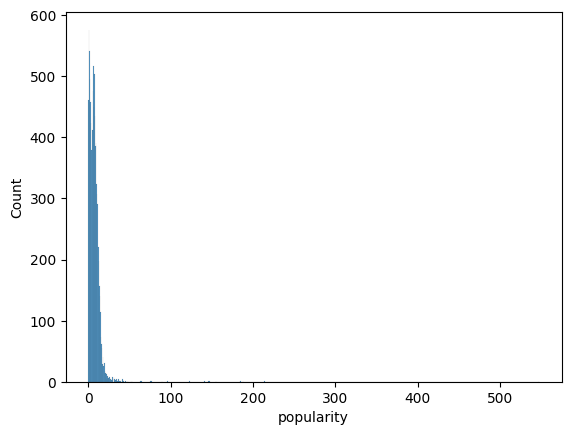

In [24]:
import seaborn as sns

sns.histplot(movies['popularity'])

> log를 이용해서 왜도 해결

In [25]:
import numpy as np

movies['popularity_log'] = np.log(movies['popularity'])

movies[['popularity_log', 'popularity']].describe()

,popularity_log,popularity
count,9151.000000,9151.000000
mean,1.559346,7.259378
std,1.159141,9.353553
min,-12.429216,0.000004
25%,1.077271,2.936654
50%,1.858137,6.411782
75%,2.287990,9.855113
max,6.305341,547.488298


<Axes: xlabel='popularity_log', ylabel='Count'>

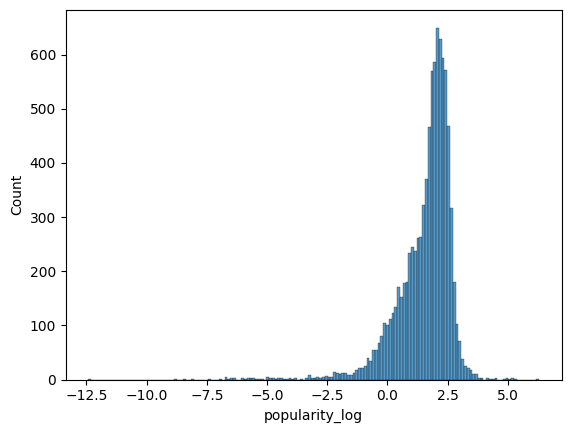

In [26]:
sns.histplot(movies['popularity_log'])

## 데이터 결측치 제거

> 각 컬럼별 결측치 비율 확인

```python
# movies.isnull().sum() -> 컬럼별 결측치의 합
# movies.shape[0] -> 전체 데이터의 수
# (movies.isnull().sum() / movies.shape[0])
# -> 각 컬럼별 결측치의 비율
(movies.isnull().sum() / movies.shape[0])\
  # 소수점 4자리까지만 표현
  .round(4)\
  # 가장 높은 비율(결측치) 순으로 정렬
  .sort_values(ascending=False)

```

In [27]:
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (9151, 9)


,0
str_genres_keywords,0.003
id,0.000
title,0.000
popularity,0.000
genres,0.000
release_date,0.000
keywords,0.000
year,0.000
popularity_log,0.000


> 결측치 데이터 제거하기

In [28]:
# 결측치 데이터 제거
movies = movies.dropna()
# 인덱스 재정의
movies = movies.reset_index(drop=True)

# 확인
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (9124, 9)


,0
id,0.0
title,0.0
genres,0.0
popularity,0.0
release_date,0.0
keywords,0.0
str_genres_keywords,0.0
year,0.0
popularity_log,0.0


# TF-IDF 기반 Contents Based Filtering
>  TF-IDF 기반 문서-단어 행렬을 활용하여 문장의 유사도 추천   
> 좀더 구체적으로 설명한면, 특정 문서 내에서 단어의 중요도를 측정하는 통계 데이터를 이용한 추천입니다.

## TF-IDF(Term Frequency-Inverse Document Frequency)

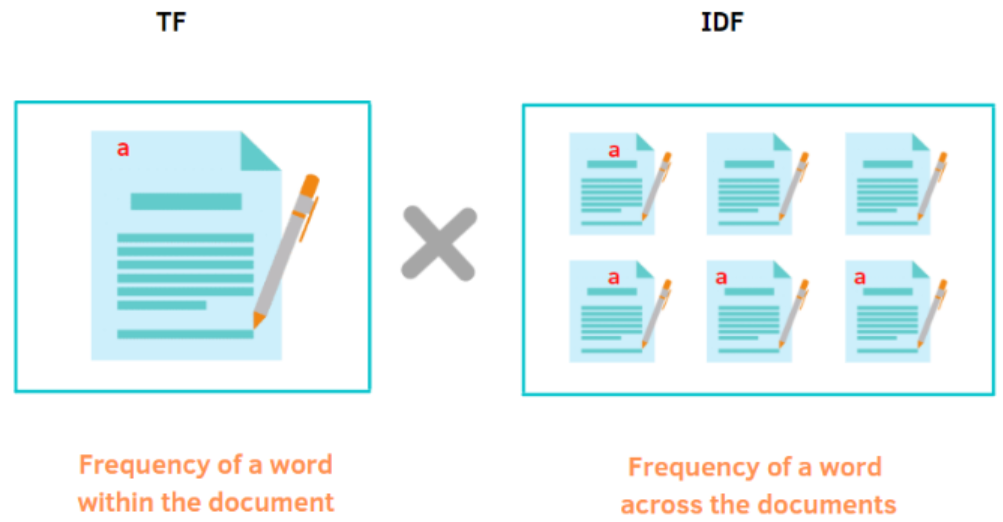

- TF(Term Frequency)
  - 특정 문서 내에서 특정 단어가 나타나는 빈도를 나타냅니다.
  - 즉, 문서 안에 단어가 얼마나 많이 사용되었는지 측정합니다.
$$
TF(t,d) = {문서\ d에서\ 단어\ t가\ 등장한\ 횟수 \over 문서\ d에\ 등장한\ 모든\ 단어의\ 수}
$$

- IDF(Inverse Document Frequency)
  - 문서 전체에서 특정 단어가 얼마나 자주 등장하는지 반대로 나타냅니다.
  - 즉, 단어가 흔한지 아니면 특별한지 측정하여 중요도를 부여합니다.

$$
IDF(t) = {총\ 문서의\ 수 \over 단어\ t를\ 포함하는\ 문서의\ 수}
$$

- TF-IDF
  - 단어의 빈도(TF)와 문서에서 해당 단어가 얼마나 자주 등장하는지(IDF)를 고려하여 단어의 중요도를 계산합니다.

$$
TF-IDF(t,d) = TF(t,d) * IDF(t)
$$

### 추천 시스템 관점에서 TF-IDF란?
  - 대부분의 영화들이 액션 장르를 포함하고 있다면, 이 단어는 많은 문서(=아이템)에서 자주 등장하므로 IDF(역문서빈도) 값이 작아지게 됩니다.
    - 따라서 액션의 TF-IDF 값은 상대적으로 작아져, 개별 아이템을 구별하는 데 덜 중요하게 간주됩니다.  
  - 반면, 어드벤처라는 장르가 특정 영화에서만 나타나는 경우, 이 단어는 드문(term) 것이므로 IDF 값이 커지고, 해당 영화에서의 TF-IDF 값도 커집니다.
    - 이는 어드벤처가 해당 아이템을 잘 특징짓는 키워드라는 의미가 됩니다.

## TF-IDF 메트릭스 생성

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf_vectorizer = TfidfVectorizer()

In [31]:
tfidf_mat = tfidf_vectorizer.fit_transform(movies['str_genres_keywords'])

In [32]:
arr_tfidf = tfidf_mat.toarray()

# shape -> (row, column) -> (전체 데이터 수, TF-IDF로 변환된 벡터 크기)
arr_tfidf.shape

(9124, 9008)

## 유사도 적용

| 지표      | 값이 클수록 유사? | 값이 작을수록 유사? |
| ------- | ---------- | ----------- |
| 코사인 유사도 | ✅          | ❌           |
| 유클리드 거리 | ❌          | ✅           |


### Euclidean Distances(유클리드 거리)

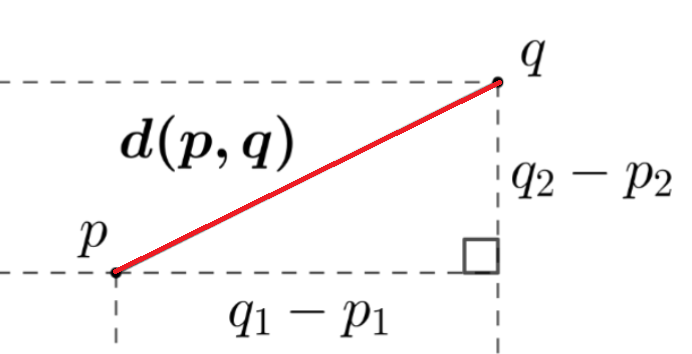

In [33]:
from sklearn.metrics.pairwise import euclidean_distances

In [34]:
similarity_of_euclidean = euclidean_distances(arr_tfidf, arr_tfidf)

In [35]:
# shape -> (전체 데이터 수, 전체 데이터 수)
similarity_of_euclidean.shape

(9124, 9124)

> 유클리드 거리에서는 값이 0에 가까울 수록 유사하다고 해석할 수 있음

In [36]:
similarity_of_euclidean

array([[0.        , 1.38652392, 1.40821742, ..., 1.37444464, 1.3966112 ,
        1.3966112 ],
       [1.38652392, 0.        , 1.41421356, ..., 1.34697187, 1.39696828,
        1.39696828],
       [1.40821742, 1.41421356, 0.        , ..., 1.41421356, 1.40409244,
        1.40409244],
       ...,
       [1.37444464, 1.34697187, 1.41421356, ..., 0.        , 1.38940096,
        1.38940096],
       [1.3966112 , 1.39696828, 1.40409244, ..., 1.38940096, 0.        ,
        0.        ],
       [1.3966112 , 1.39696828, 1.40409244, ..., 1.38940096, 0.        ,
        0.        ]])

> 유클리드 거리의 값을 index로 변경

In [37]:
sorted_similarity_of_euclidean = similarity_of_euclidean.argsort()

sorted_similarity_of_euclidean

array([[   0, 1477, 7536, ..., 5326, 4727, 8196],
       [   1, 7339, 1917, ..., 5943, 4727, 8196],
       [   2, 8115, 2745, ..., 3568, 5326, 8196],
       ...,
       [9121, 4250, 4249, ..., 4727, 2003, 3753],
       [9122, 8647, 8646, ..., 5942, 5939, 8020],
       [9122, 8647, 8646, ..., 5942, 5939, 8020]])

#### 검증하기

> 0번째 영화에 대한 유사도 데이터

In [38]:
movie0_index_of_euclidean = sorted_similarity_of_euclidean[0]
movie0_index_of_euclidean

array([   0, 1477, 7536, ..., 5326, 4727, 8196])

> 0번째 영화와 가장 유사한 영화 index

In [39]:
movie_index_of_max = movie0_index_of_euclidean[1]
movie_index_of_max

np.int64(1477)

> 0번째 영화와 가장 유사한 영화 index의 유클리드 거리값   
> 유클리드 거리값은 작을 수록 유사함

In [40]:
similarity_of_euclidean[0][movie_index_of_max]

np.float64(0.9563269468781429)

In [41]:
movies[['title', 'str_genres_keywords']].iloc[[0, movie_index_of_max], :]

,title,str_genres_keywords
0,Toy Story,Animation Comedy Family boy boy next door frie...
1477,Small Soldiers,Action Adventure Comedy Fantasy Science Fictio...


#### 추천 with 유클리드 거리

In [42]:
def recommendation_of_euclidean(title_name, top_k=5):
  # 기준 영화 추출
  movie_of_title = movies[movies['title'] == title_name]
  print(f"{title_name}의 장르: {movie_of_title['str_genres_keywords'].values[0]}")

  # 기준 영화 인덱스
  movie_index_of_title = movie_of_title.index.values[0]

  # 기준 영화를 기준으로 가장 유사도가 높은 영화들의 인덱스 추출
  similar_indexes = sorted_similarity_of_euclidean[movie_index_of_title, :(top_k*2)]
  # 메트릭스(2차원의 데이터)를 벡터(1차원의 데이터)로 변환
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != movie_index_of_title]

  # 유사도 기반으로 추출된 영화 추천
  return movies.iloc[similar_indexes].sort_values(by=['popularity_log','year'], ascending=False)[:top_k]

In [43]:
recommendation_movies = recommendation_of_euclidean('Robin Hood')

recommendation_movies[['title', 'str_genres_keywords', 'popularity_log', 'year']]

Robin Hood의 장르: Animation Family animal animal as human animation bear forest fox hero outlaw right and justice robin hood sherwood forest teacher thief


,title,str_genres_keywords,popularity_log,year
465,Robin Hood: Men in Tights,Comedy arrow forest parody robin hood spoof ta...,2.841221,1993
6195,Valiant,3d Adventure Animation Family animal animation,2.471216,2005
6520,Open Season,Adventure Animation Family bear bunny chase de...,2.463363,2006
7514,Robin Hood,Action Adventure archer bow and arrow king of ...,2.357842,2010
832,The Fox and the Hound,Adventure Animation Drama Family animal based ...,2.322104,1981


### Cosine Similarity(코사인 유사도)

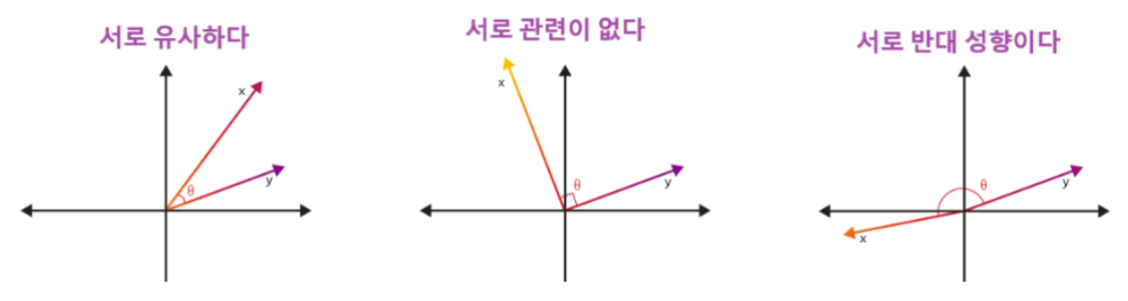

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
similarity_of_cosine = cosine_similarity(arr_tfidf, arr_tfidf)

# shape -> (전체 데이터 수, 전체 데이터 수)
similarity_of_cosine.shape

(9124, 9124)

> 코사인 유사도에서는 값이 1에 가까울 수록 유사하다고 해석할 수 있음

In [46]:
similarity_of_cosine

array([[1.        , 0.03877571, 0.00846186, ..., 0.05545096, 0.02473857,
        0.02473857],
       [0.03877571, 1.        , 0.        , ..., 0.09283339, 0.02423982,
        0.02423982],
       [0.00846186, 0.        , 1.        , ..., 0.        , 0.0142622 ,
        0.0142622 ],
       ...,
       [0.05545096, 0.09283339, 0.        , ..., 1.        , 0.03478249,
        0.03478249],
       [0.02473857, 0.02423982, 0.0142622 , ..., 0.03478249, 1.        ,
        1.        ],
       [0.02473857, 0.02423982, 0.0142622 , ..., 0.03478249, 1.        ,
        1.        ]])

> 코사인 유사도의 값을 index로 변경

In [47]:
sorted_similarity_of_cosine = similarity_of_cosine.argsort()[:, ::-1]

sorted_similarity_of_cosine

array([[   0, 1477, 7536, ..., 5846, 5847, 3233],
       [   1, 7339, 1917, ..., 6067, 6068, 3946],
       [   2, 8115, 2745, ..., 3089, 3090, 3109],
       ...,
       [9121, 9120, 4250, ..., 4628, 4629, 4615],
       [9123, 9122, 8647, ..., 6197, 6199, 3779],
       [9123, 9122, 8647, ..., 6197, 6199, 3779]])

#### 검증하기

> 0번째 영화에 대한 유사도 데이터

In [48]:
movie0_index_of_similarity = sorted_similarity_of_cosine[0]

movie0_index_of_similarity

array([   0, 1477, 7536, ..., 5846, 5847, 3233])

> 0번째 영화와 가장 유사한 영화 index

In [49]:
movie_index_of_max = movie0_index_of_similarity[1]
movie_index_of_max

np.int64(1477)

> 0번째 영화와 가장 유사한 영화 index의 코사인 유사도 값   
> 코사인 유사도 값은 1에 가까울 수록 유사함

In [50]:
similarity_of_cosine[0][movie_index_of_max]

np.float64(0.5427193853373649)

In [51]:
movies[['title', 'str_genres_keywords']].iloc[[0, movie_index_of_max], :]

,title,str_genres_keywords
0,Toy Story,Animation Comedy Family boy boy next door frie...
1477,Small Soldiers,Action Adventure Comedy Fantasy Science Fictio...


#### 추천 with 코사인 유사도

In [52]:
def recommendation_of_cosine(title_name, top_k=5):
  # 기준 영화 추출
  movie_of_title = movies[movies['title'] == title_name]
  print(f"{title_name}의 장르: {movie_of_title['str_genres_keywords'].values[0]}")

  # 기준 영화 인덱스
  movie_index_of_title = movie_of_title.index.values[0]

  # 기준 영화를 기준으로 가장 유사도가 높은 영화들의 인덱스 추출
  similar_indexes = sorted_similarity_of_cosine[movie_index_of_title, :(top_k*2)]
  # 메트릭스(2차원의 데이터)를 벡터(1차원의 데이터)로 변환
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != movie_index_of_title]

  # 유사도 기반으로 추출된 영화 추천
  return movies.iloc[similar_indexes].sort_values(by=['popularity_log','year'], ascending=False)[:top_k]

In [53]:
recommendation_movies = recommendation_of_cosine('Robin Hood')

recommendation_movies[['title', 'str_genres_keywords', 'popularity_log', 'year']]

Robin Hood의 장르: Animation Family animal animal as human animation bear forest fox hero outlaw right and justice robin hood sherwood forest teacher thief


,title,str_genres_keywords,popularity_log,year
465,Robin Hood: Men in Tights,Comedy arrow forest parody robin hood spoof ta...,2.841221,1993
6195,Valiant,3d Adventure Animation Family animal animation,2.471216,2005
6520,Open Season,Adventure Animation Family bear bunny chase de...,2.463363,2006
7514,Robin Hood,Action Adventure archer bow and arrow king of ...,2.357842,2010
832,The Fox and the Hound,Adventure Animation Drama Family animal based ...,2.322104,1981
